# Análise da Eficiência do Planejamento de Materiais
Este relatório tem como objetivo realizar um diagnóstico da consistência do planejamento de materiais em uma cadeia de suprimentos, a partir da análise dos dados operacionais.

A verificação parte de uma abordagem investigativa, buscando compreender como o planejamento se relaciona com a demanda, produtos e outros aspectos. O foco está em identificar padrões, verificar a consistência das operações e destacar tanto pontos de eficiência quanto possíveis oportunidades de melhoria. Para isso, foi conduzida uma Análise Exploratória de Dados (EDA) com os seguintes objetivos:

* avaliar a consistência do planejamento
* identificar padrões operacionais, como regularidade, sazonalidade ou rotina
* identificar possíveis componentes críticos à operação
* observar tendências ao longo do tempo
* analisar o desempenho do planejamento sob diferentes estratégias de produção

Os dados utilizados foram obtidos do seguinte link: https://www.kaggle.com/datasets/veeralakrishna/inventory

**Descrição das principais colunas**
* COMP_ITEM_ID: Identificador do componente
* PRODUCT_ID / PRODUCT_NAME: Identificação do produto final associado ao componente
* COMMODITY: Categoria ou tipo do componente
* SUPPLY_CHAIN_TYPE: Estratégia de produção (ex: Build To Stock, Build To Order, Configure To Order, Build To Plan)
* VRSN_WEEK_STRT_DATE: Data em que o planejamento foi realizado
* DMND_WEEK_STRT_DATE: Data em que a demanda ocorreu (quando o item foi necessário)
* LEAD_TIME: Tempo necessário para reposição do item
* MRP_FCST_QTY: Quantidade prevista no planejamento

A análise combina o uso de SQL para manipulação e preparação dos dados, com Python, utilizado para exploração, visualização e interpretação dos resultados.

In [20]:
# importando as bibliotecas necessárias
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## A) Extração dos dados (EXTRACT)
* Os dados foram importados utilizando a biblioteca DuckDB integrada ao Python, permitindo a leitura direta do arquivo .csv e sua transformação em uma tabela relacional em memória. 
* A escolha pelo SQL se deve pela linguagem ser amplamente utilizada no mercado. O mesmo foi utilizado principalmente para extração, filtragem e preparação dos dados. 
* Posteriormente, o python foi utilizado para análise e visualização.

In [21]:
con = duckdb.connect()  # cria uma conexão com um banco de dados em memória (temporário)

con.execute(r"""
CREATE TABLE inventory AS  -- cria uma tabela chamada "inventory"
SELECT * 
FROM read_csv_auto('C:/Users/littl/OneDrive/Área de Trabalho/Dados/Portfolio/Supply chain/inventory.csv')""")

df = con.execute(""" SELECT * 
FROM inventory  -- consulta a tabela criada
LIMIT 10        -- traz apenas 10 linhas para visualização rápida
""").df()        # converte o resultado para DataFrame (para visualizar no notebook)

df  # exibe o resultado

,CCN,COMP_ITEM_ID,COMMODITY,LEAD_TIME,CFG,ITM_DESC,CHANNEL_ID,PRODUCT_ID,PRODUCT_NAME,SCHEDULER_NAME,DMND_WEEK_STRT_DATE,VRSN_WEEK_STRT_DATE,MRP_FCST_QTY,SUPPLY_CHAIN_TYPE,DW_PKG_UPD_DTS
0,M10000,DKC2X,ODD,13,RMSD_9_5_DVD_SATA_Bare_Std,"DVD,8X,SATA,9.5T,DU90N,HLDS",5000004,57368,FIGTREECTO,NORMAWARZURA_MAT (RMSD_APJ),2015-10-10,2015-10-10,0,CTO,51:30.0
1,DAO,9GTFM,ODM Mechanical,13,9GTFM_CFG,"ASSY,CMRA,9343",1865,61590,DINO2BTX,BTX_XPS_NOTEBOOKS,2015-12-19,2015-10-17,78,BTO,02:40.4
2,E10000,GKM4Y,ODD Mechanical,13,GKM4Y_SCR,"SCR,M2X5,FLH,MSCR,CS,E6320",2190,62856,PARKCITY15BTX,BTX_LATITUDE,2016-03-05,2015-12-19,642,BTO,02:40.4
3,C40000,FW1MN,Battery,13,OAK14/15_4_2.8_PRIMARY,"BTRY,PRI,40WHR,4C,LITH,SIMPLO",5000948,55725,CEDAR15HSWBTX,BTX_PERSONAL_NOTEBOOKS,2016-09-17,2015-11-07,0,BTO,02:40.4
4,C40000,9RRC7,MOUSE,8,MSE_ENTRY_OPTICAL_INDIGO_POS,"KIT,MSE,USB,POS,LOGI,MS111",5000947,54265,GENERAL SFF BTX,BTX_PERSONAL_DESKTOPS,2016-04-30,2016-01-02,0,BTS,21:42.6
5,DAO,VN3N0,Battery,13,Iris/Tulip/VG14/Loveland_15_17_4_2.8_PRIMARY,"BTRY,PRI,40WHR,4C,LITH,SIMPLO",1865,60147,TULIP15BDWBTX,BTX_PERSONAL_NOTEBOOKS,2016-04-09,2016-01-16,0,BTO,14:57.8
6,E10000,G1XNT,HDD_NB_DT,8,HDD_1TB_SATA_6G_DT,"HD,1TB,S3,7.2K,512E,SGT-GRDABP",2190,54358,GREATBEAR MT BTX,BTX_VOSTRO_DESKTOPS,2016-06-18,2016-02-06,24,BTO,57:56.9
7,E10000,8CFJ3,LCD,15,15.6HD_AG_ULSLIM_E7_NBLCD,"LCD,15.6HD,HC,EDP,AUO",2190,60705,VANGOGH15BDWBTX,BTX_VOSTRO_NOTEBOOKS,2017-01-07,2016-04-16,0,BTS,46:40.9
8,I10000,FHKK7,ODM Mechanical,13,Camera_NB HD 2x mic E6 FHKK7,"ASSY,CMRA,HD,0.92M,W/MIC",5000236,57527,HOUSTON15CTO,PHOAY_HOON_TAN (LATI LCD),2015-12-26,2016-01-09,232,CTO,13:36.0
9,C40000,2T530,CORD,10,PWr_CORD_2T530,"KIT,CORD,ADPT,PWR,125V,JPN",5000947,54361,GREATBEAR ST BTX,BTX_VOSTRO_DESKTOPS,2016-01-16,2015-11-21,0,BTS,02:40.4


## B) Transformação dos dados (TRANSFORM)
### B.1) Verificação dos tipos de dados 
* A verificação dos tipos de dados em cada coluna é necessário para garantir a consistência das operações realizadas durante as análises.

In [22]:
# Verificando o tipo de dados das colunas
types_column = con.execute("""
DESCRIBE inventory  -- mostra nome da coluna e o tipo detectado
""").df()  # transforma o resultado em DataFrame para visualizar
types_column

,column_name,column_type,null,key,default,extra
0,CCN,VARCHAR,YES,None,None,None
1,COMP_ITEM_ID,VARCHAR,YES,None,None,None
2,COMMODITY,VARCHAR,YES,None,None,None
3,LEAD_TIME,BIGINT,YES,None,None,None
4,CFG,VARCHAR,YES,None,None,None
5,ITM_DESC,VARCHAR,YES,None,None,None
6,CHANNEL_ID,BIGINT,YES,None,None,None
7,PRODUCT_ID,BIGINT,YES,None,None,None
8,PRODUCT_NAME,VARCHAR,YES,None,None,None
9,SCHEDULER_NAME,VARCHAR,YES,None,None,None


* Os tipos de dados coincidem com as informações preenchidas, portanto, não há ações a serem realizadas nesta etapa.
### B.2) Verificação de informações ausentes no banco de dados
* As linhas vazias devem ser tratados pois podem comprometer a análise, gerar erros em cálculos e distorcer resultados estatísticos, além de indicar possíveis falhas no processo de coleta ou registro dos dados.

In [23]:
# Calculando o número de linhas vazias
df_nulls = con.execute("""
SELECT 
    COUNT(*) AS total_linhas,
    SUM(CASE WHEN CCN IS NULL OR TRIM(CCN) = '' THEN 1 ELSE 0 END) AS perc_null_ccn,
    SUM(CASE WHEN COMP_ITEM_ID IS NULL OR TRIM(COMP_ITEM_ID) = '' THEN 1 ELSE 0 END) AS perc_null_comp_item,
    SUM(CASE WHEN COMMODITY IS NULL OR TRIM(COMMODITY) = '' THEN 1 ELSE 0 END) AS perc_null_commodity,
    SUM(CASE WHEN CFG IS NULL OR TRIM(CFG) = '' THEN 1 ELSE 0 END) AS perc_null_cfg,
    SUM(CASE WHEN ITM_DESC IS NULL OR TRIM(ITM_DESC) = '' THEN 1 ELSE 0 END) AS perc_null_itm_desc,
    SUM(CASE WHEN PRODUCT_NAME IS NULL OR TRIM(PRODUCT_NAME) = '' THEN 1 ELSE 0 END) AS perc_null_product_name,
    SUM(CASE WHEN SCHEDULER_NAME IS NULL OR TRIM(SCHEDULER_NAME) = '' THEN 1 ELSE 0 END) AS perc_null_scheduler
FROM inventory""").df()

df_nulls

,total_linhas,perc_null_ccn,perc_null_comp_item,perc_null_commodity,perc_null_cfg,perc_null_itm_desc,perc_null_product_name,perc_null_scheduler
0,106367,0.0,0.0,0.0,0.0,0.0,0.0,0.0


* Não há linhas sem informações, portanto, não há ações a serem feitas nesta etapa.
### B.3) Classificação da Adequação do Planejamento à Demanda
Foi criada uma classificação para avaliar a relação entre planejamento e demanda com base nas datas de planejamento, data de demanda e no lead time  
- Considera-se dentro do plano (ON SCHEDULE) quando o planejamento ocorre antes da demanda, com tempo suficiente para reposição
- Em atraso (DELAYED) quando o planejamento ocorre antes da demanda, mas com tempo insuficiente para reposição 
- Correção emergencial (CORRECTION) quando o planejamento ocorre após a data da demanda 
- Indefinido (UNDEFINED) para os casos que não se encaixam em nenhuma das citadas anteriormente

In [24]:
con.execute("""
CREATE TABLE inventory_processed AS  -- cria nova tabela
SELECT 
    *,  -- mantém todas as colunas originais

    -- cria a coluna de classificação
    CASE    
        WHEN VRSN_WEEK_STRT_DATE > DMND_WEEK_STRT_DATE 
        THEN 'CORRECTION'

        WHEN VRSN_WEEK_STRT_DATE <= DMND_WEEK_STRT_DATE 
             AND (DMND_WEEK_STRT_DATE - VRSN_WEEK_STRT_DATE) >= LEAD_TIME
        THEN 'ON SCHEDULE'

        WHEN VRSN_WEEK_STRT_DATE <= DMND_WEEK_STRT_DATE 
             AND (DMND_WEEK_STRT_DATE - VRSN_WEEK_STRT_DATE) < LEAD_TIME
        THEN 'DELAYED'

        ELSE 'UNDEFINED'
    END AS PLAN_CLASSIFICATION

FROM inventory
""")


## C) Análises


### C.1) Comportamento geral do planejamento
#### a) Distribuição das Classificações de Planejamento
* Nesta etapa, busca-se analisar proporção de demandas dentro do plano, em atraso ou corretivo (ON SCHEDULE, DELAYED e CORRECTION, respectivamente), com o objetivo de avaliar o comportamento geral do processo.

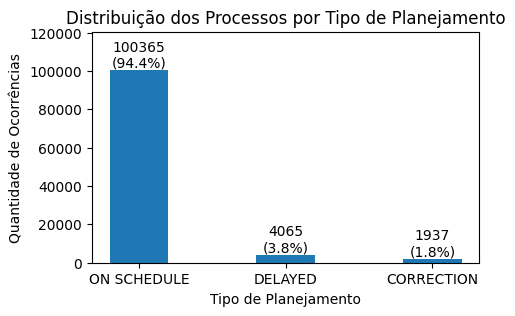

In [25]:
planning_count = con.execute("""
SELECT
    PLAN_CLASSIFICATION,
    COUNT(*) AS total,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS percentage
FROM inventory_processed
GROUP BY PLAN_CLASSIFICATION
ORDER BY total DESC""").df()

plt.figure(figsize=(5,3))
bars = plt.bar(
    planning_count['PLAN_CLASSIFICATION'],
    planning_count['total'], width=0.4)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    perc = planning_count.loc[i, 'percentage']
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{int(yval)}\n({perc:.1%})',
        ha='center',
        va='bottom')

plt.ylim(0, planning_count['total'].max() * 1.2)
plt.title('Distribuição dos Processos por Tipo de Planejamento')
plt.xlabel('Tipo de Planejamento')
plt.ylabel('Quantidade de Ocorrências')
plt.show()

* Observa-se que a maior parte das ocorrências está concentrada em ON SCHEDULE, indicando que, na maioria dos casos, o planejamento ocorre dentro do prazo em relação ao lead time.



#### b) Quantidade de informações nulas pela classificação do planejamento
* A seguir, analisa-se a relação entre a classificação do planejamento (dentro do plano, com atraso ou corretivo) e a quantidade de demandas que foram nulas.

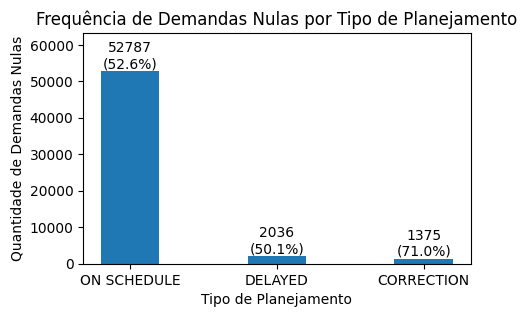

In [26]:
zero_demanda_planning = con.execute("""
SELECT
    PLAN_CLASSIFICATION,
    COUNT(*) AS total,
    SUM(CASE WHEN MRP_FCST_QTY = 0 THEN 1 ELSE 0 END) AS zero_demands,
    SUM(CASE WHEN MRP_FCST_QTY = 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS pct_zero
FROM inventory_processed
GROUP BY PLAN_CLASSIFICATION
ORDER BY zero_demands DESC
""").df()

plt.figure(figsize=(5,3))

bars = plt.bar(
    zero_demanda_planning['PLAN_CLASSIFICATION'],
    zero_demanda_planning['zero_demands'],
    width=0.4
)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    perc = zero_demanda_planning.loc[i, 'pct_zero']
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{int(yval)}\n({perc:.1%})',
        ha='center',
        va='bottom'
    )

plt.ylim(0, zero_demanda_planning['zero_demands'].max() * 1.2)
plt.title('Frequência de Demandas Nulas por Tipo de Planejamento')
plt.xlabel('Tipo de Planejamento')
plt.ylabel('Quantidade de Demandas Nulas')
plt.show()

* Observa-se uma alta ocorrência de demandas nulas em todas as classificações de planejamento (ON SCHEDULE, DELAYED e CORRECTION). Esse comportamento indica que a geração de planejamento nem sempre está associada à necessidade real de reposição.
* Isso ocorre porque a classificação adotada considera apenas a relação entre datas e lead time, não refletindo a disponibilidade de estoque. Assim, mesmo em cenários com atraso ou correção, pode não haver necessidade real de reposição.
* De forma geral, os resultados sugerem que o processo de planejamento atua como uma rotina de verificação, na qual nem todas as execuções resultam em demanda efetiva.
* A elevada frequência de valores nulos pode indicar tanto um sistema eficiente, com boa disponibilidade de materiais, quanto um possível excesso de acionamentos operacionais. A interpretação depende do contexto do processo.


### C.2) Entendimento estrutural dos dados (nulos)
#### a) Quantidade de informações nulas por SUPPLY_CHAIN_TYPE
* Aqui, procura-se identificar alguma relação entre o tipo de estratégia de produção e a concentração de demandas nulas. 

In [27]:
zero_demand_SupChtype = con.execute("""SELECT
    SUPPLY_CHAIN_TYPE,
    COUNT(*) AS total,
    SUM(CASE WHEN MRP_FCST_QTY = 0 THEN 1 ELSE 0 END) AS zero_demands,
    SUM(CASE WHEN MRP_FCST_QTY = 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS zero_rate
FROM inventory_processed
GROUP BY SUPPLY_CHAIN_TYPE
ORDER BY zero_rate DESC; """).df()

print(zero_demand_SupChtype)

  SUPPLY_CHAIN_TYPE  total  zero_demands  zero_rate
0               BTP   4213        3636.0   0.863043
1               BTS  13871       11218.0   0.808738
2               BTO  26562       13657.0   0.514156
3               CTO  61721       27687.0   0.448583


* Observa-se uma alta proporção de demandas com quantidade prevista igual a zero ao longo do dataset, para todas as estratérias de produção. Esse comportamento sugere que o processo de planejamento não está sendo utilizado exclusivamente como um gatilho para reposição de estoque, mas também como um mecanismo de verificação das necessidades. 
* Em sistemas MRP (Material Requirements Planning), é comum que execuções periódicas avaliem a necessidade de reposição mesmo quando há estoque suficiente. Dessa forma, a alta presença desses casos não indica necessariamente ineficiência, podendo refletir uma rotina operacional do sistema. 
* Ainda assim, essa evidência levanta a necessidade de investigações adicionais para distinguir entre um comportamento esperado do processo e possíveis oportunidades de melhoria na precisão do planejamento.


#### b) Quantidade de informações nulas por combinação de produtos e componentes
* Agora, o objetivo é identificar quais combinações de produto e componente mais concentravam demandas nulas.

In [28]:
zero_demand_prod_comp = con.execute("""SELECT
    PRODUCT_ID,
    COMP_ITEM_ID,
    COUNT(*) AS total,
    SUM(CASE WHEN MRP_FCST_QTY = 0 THEN 1 ELSE 0 END) AS zero_demands,
    SUM(CASE WHEN MRP_FCST_QTY = 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS zero_rate
FROM inventory_processed
GROUP BY PRODUCT_ID, COMP_ITEM_ID
ORDER BY zero_demands DESC; """).df()

print(zero_demand_prod_comp.head(50))

    PRODUCT_ID COMP_ITEM_ID  total  zero_demands  zero_rate
0        61684        DU555    310         273.0   0.880645
1        57519        GKM4Y    185         168.0   0.908108
2        60150        4270E    213         149.0   0.699531
3        57513        4270E    155         143.0   0.922581
4        57499        4270E    160         132.0   0.825000
5        54091        9CF26    165         131.0   0.793939
6        60705        NJG52    151         130.0   0.860927
7        60150        N2VFR    174         125.0   0.718391
8        56744        4270E    137         123.0   0.897810
9        61590        JHXPY    164         115.0   0.701220
10       62408        9M9FK    174         115.0   0.660920
11       60150        9M9FK    162         114.0   0.703704
12       57499        FHKK7    133         112.0   0.842105
13       60150        VN3N0    175         111.0   0.634286
14       54091        29MKK    132         110.0   0.833333
15       60150        NWMX1    149      

* Observa-se uma alta frequência de demandas nulas, para grande parte das combinações produto/componente (70-90% das ocorrências de cada combinação), indicando que esse comportamento é recorrente no conjunto de dados.
* A seguir, observa-se somente os componentes que possuem maior número de demandas com requisição quantitativa nula.

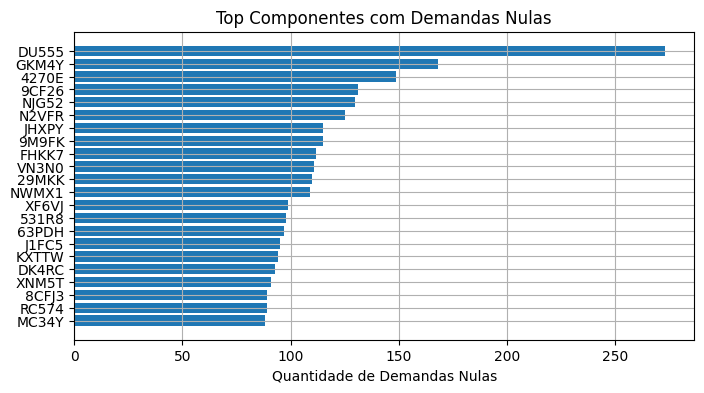

In [29]:
top_filtered = zero_demand_prod_comp[
    zero_demand_prod_comp['total'] >= 20
].sort_values(by='zero_demands', ascending=False).head(30)

plt.figure(figsize=(8,4))
plt.barh(
    top_filtered['COMP_ITEM_ID'].astype(str),
    top_filtered['zero_demands']
)
plt.gca().invert_yaxis()
plt.grid()
plt.title('Top Componentes com Demandas Nulas')
plt.xlabel('Quantidade de Demandas Nulas')
plt.show()

* Novamente, há uma grande quantidade de casos em que a demanda foi nula. 
* Pode-se inferir, a partir das diferentes análises (perspectivas C.1, a e b, e C.2, a e b) realizadas sobre a ocorrência de demandas nulas, que a abertura de processos de planejamento de reposição faz parte de uma rotina operacional do sistema.


### C.3) Análise do comportamento da demanda (volume)
#### a) Visão estatística do volume demandado por componente
* O objetivo é identificar requisições com volume fora do padrão esperado, com base nos percentis, que possam indicar instabilidade ou irregularidade no comportamento da demanda.

In [30]:
# volume demandado
freq_outliers = con.execute("""
WITH base AS (
    SELECT
        COMP_ITEM_ID,
        MRP_FCST_QTY AS frequency
    FROM inventory_processed
),

stats AS (
    SELECT
        COMP_ITEM_ID,
        QUANTILE_CONT(frequency, 0.25) AS p25,
        QUANTILE_CONT(frequency, 0.75) AS p75
    FROM base
    GROUP BY COMP_ITEM_ID
),

bounds AS (
    SELECT
        COMP_ITEM_ID,
        p25,
        p75,
        (p25 - 1.5 * (p75 - p25)) AS lower_bound,
        (p75 + 1.5 * (p75 - p25)) AS upper_bound
    FROM stats
),

outliers AS (
    SELECT
        b.COMP_ITEM_ID,
        b.frequency,
        bd.lower_bound,
        bd.upper_bound,
        CASE WHEN b.frequency < bd.lower_bound THEN 1 ELSE 0 END AS outlier_below,
        CASE WHEN b.frequency > bd.upper_bound THEN 1 ELSE 0 END AS outlier_above,
        CASE WHEN b.frequency = 0 THEN 1 ELSE 0 END AS zero_flag
    FROM base b
    JOIN bounds bd
        ON b.COMP_ITEM_ID = bd.COMP_ITEM_ID
)

SELECT
    COMP_ITEM_ID,

    QUANTILE_CONT(frequency, 0.25) AS p25,
    QUANTILE_CONT(frequency, 0.50) AS p50,
    QUANTILE_CONT(frequency, 0.75) AS p75,
    QUANTILE_CONT(frequency, 0.90) AS p90,

    MIN(frequency) AS min_freq,
    MAX(frequency) AS max_freq,

    SUM(outlier_above) AS count_outliers_above,
    SUM(outlier_below) AS count_outliers_below,

    MAX(CASE WHEN outlier_above = 1 THEN frequency ELSE NULL END) AS max_outlier_value,
    MIN(CASE WHEN outlier_below = 1 THEN frequency ELSE NULL END) AS min_outlier_value,

    SUM(zero_flag) AS zero_count,
    SUM(zero_flag) * 1.0 / COUNT(*) AS zero_ratio,

    COUNT(*) AS total_occurrences

FROM outliers

GROUP BY COMP_ITEM_ID

HAVING total_occurrences > 1

ORDER BY count_outliers_above DESC, max_outlier_value DESC
""").df()

freq_outliers

,COMP_ITEM_ID,p25,p50,p75,p90,min_freq,max_freq,count_outliers_above,count_outliers_below,max_outlier_value,min_outlier_value,zero_count,zero_ratio,total_occurrences
0,4270E,0.0,0.0,14.50,192.0,0,43200,1034.0,0.0,43200,<NA>,3042.0,0.578437,5259
1,NWMX1,0.0,0.0,9.00,138.0,0,6491,562.0,0.0,6491,<NA>,1821.0,0.679224,2681
2,9M9FK,0.0,0.0,38.00,235.6,0,15000,470.0,0.0,15000,<NA>,1517.0,0.573535,2645
3,9CF26,0.0,0.0,24.00,193.6,0,7239,271.0,0.0,7239,<NA>,921.0,0.610338,1509
4,63PDH,0.0,0.0,20.00,481.6,0,78732,270.0,0.0,78732,<NA>,937.0,0.690494,1357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2596,05K81,36.5,73.0,109.50,131.4,0,146,0.0,0.0,<NA>,<NA>,1.0,0.500000,2
2597,G97C9,0.0,0.0,0.00,0.0,0,0,0.0,0.0,<NA>,<NA>,4.0,1.000000,4
2598,J976Y,1.0,5.0,20.25,31.5,0,35,0.0,0.0,<NA>,<NA>,1.0,0.125000,8
2599,1FXWJ,119.5,123.0,185.50,223.0,116,248,0.0,0.0,<NA>,<NA>,0.0,0.000000,3


* Alguns componentes apresentam volumes de demanda muito acima do padrão esperado, com valores máximos significativamente superiores aos percentis, indicando a presença de requisições atípicas.


### C.4) Identificação de componentes críticos
#### a) Componentes com Maiores Picos de Demanda
* Nesta etapa, a tabela freq_outliers (tabela de percentis) foi ordenada de forma decrescente com base no valor máximo de volume requisitado (max_freq) por componente.
* O objetivo é destacar itens que apresentaram requisições significativamente acima do padrão e avaliar seu potencial de criticidade.
* Consideram-se como potencialmente críticos os componentes que apresentam comportamento de demanda fora do padrão, caracterizado por picos elevados de volume ou recorrência de valores extremos, podendo impactar o processo de reposição.

In [31]:
# demandas com mais picos
top_peaks = con.execute(""" 
SELECT *
FROM freq_outliers
ORDER BY max_freq DESC
LIMIT 10
""").df()

top_peaks

,COMP_ITEM_ID,p25,p50,p75,p90,min_freq,max_freq,count_outliers_above,count_outliers_below,max_outlier_value,min_outlier_value,zero_count,zero_ratio,total_occurrences
0,GKM4Y,0.0,0.0,2.0,225.8,0,91740,241.0,0.0,91740,<NA>,752.0,0.728682,1032
1,63PDH,0.0,0.0,20.0,481.6,0,78732,270.0,0.0,78732,<NA>,937.0,0.690494,1357
2,09NK2,0.0,0.0,13.0,192.0,0,53932,68.0,0.0,53932,<NA>,223.0,0.653959,341
3,N6R8G,0.0,0.0,4.0,490.3,0,50259,48.0,0.0,50259,<NA>,152.0,0.678571,224
4,4270E,0.0,0.0,14.5,192.0,0,43200,1034.0,0.0,43200,<NA>,3042.0,0.578437,5259
5,GPFNK,0.0,0.0,1.0,74.8,0,43008,63.0,0.0,43008,<NA>,228.0,0.740260,308
6,6TM1C,0.0,0.0,49.5,473.8,0,34848,61.0,0.0,34848,<NA>,190.0,0.560472,339
7,KTCCN,1.0,7.0,532.0,3318.6,0,27235,6.0,0.0,27235,<NA>,6.0,0.153846,39
8,61H6H,0.0,0.0,109.5,434.4,0,21410,61.0,0.0,21410,<NA>,201.0,0.519380,387
9,9RRC7,0.0,0.0,0.0,153.0,0,20533,127.0,0.0,20533,<NA>,396.0,0.757170,523


* A presença de um número relevante de outliers superiores (count_outliers_above) mostra que esses picos não são eventos isolados, mas recorrentes ao longo do tempo.



#### b) Componentes com Maior Frequência de Valores Atípicos (Outliers)
* Nesta etapa, os componentes foram ordenados com base na quantidade de ocorrências classificadas como outliers superiores (count_outliers_above). 
* O objetivo é identificar itens que apresentam maior frequência de valores de demanda muito acima do padrão esperado.

In [32]:
# muitos outliers
top_outliers = con.execute("""
SELECT *
FROM freq_outliers
ORDER BY count_outliers_above DESC
LIMIT 10
""").df()

top_outliers

,COMP_ITEM_ID,p25,p50,p75,p90,min_freq,max_freq,count_outliers_above,count_outliers_below,max_outlier_value,min_outlier_value,zero_count,zero_ratio,total_occurrences
0,4270E,0.0,0.0,14.5,192.0,0,43200,1034.0,0.0,43200,<NA>,3042.0,0.578437,5259
1,NWMX1,0.0,0.0,9.0,138.0,0,6491,562.0,0.0,6491,<NA>,1821.0,0.679224,2681
2,9M9FK,0.0,0.0,38.0,235.6,0,15000,470.0,0.0,15000,<NA>,1517.0,0.573535,2645
3,9CF26,0.0,0.0,24.0,193.6,0,7239,271.0,0.0,7239,<NA>,921.0,0.610338,1509
4,63PDH,0.0,0.0,20.0,481.6,0,78732,270.0,0.0,78732,<NA>,937.0,0.690494,1357
5,GKM4Y,0.0,0.0,2.0,225.8,0,91740,241.0,0.0,91740,<NA>,752.0,0.728682,1032
6,KKMYD,0.0,2.0,12.0,65.0,0,6077,220.0,0.0,6077,<NA>,524.0,0.392216,1336
7,N2M64,0.0,0.0,5.5,93.4,0,2978,214.0,0.0,2978,<NA>,686.0,0.700715,979
8,VN3N0,0.0,0.0,26.5,225.0,0,6730,188.0,0.0,6730,<NA>,667.0,0.659743,1011
9,NJG52,0.0,0.0,5.0,189.0,0,5102,170.0,0.0,5102,<NA>,505.0,0.705307,716


* Observa-se que alguns componentes apresentam elevada quantidade de outliers superiores, indicando que eventos de alta demanda ocorrem com frequência relevante ao longo do período analisado.
* A recorrência desses valores atípicos sugere que esses componentes possuem comportamento de demanda menos previsível.
* Além disso, muitos desses componentes também apresentam alta proporção de demandas nulas, evidenciando um padrão combinado de baixa demanda na maior parte do tempo e picos recorrentes em momentos específicos.



#### c) Componentes com Maior Variabilidade de Demanda
* Ordena-se a tabela freq_outliers conforme a variabilidade do volume demandado, definida pela diferença entre os percentis p90 e p25. 
* Essa métrica permite avaliar a dispersão da demanda ao da base de dados.

In [33]:
# alta variabilidade
top_variability = con.execute("""
SELECT *,
       (p90 - p25) AS variability
FROM freq_outliers
ORDER BY variability DESC
LIMIT 10
""").df()

top_variability

,COMP_ITEM_ID,p25,p50,p75,p90,min_freq,max_freq,count_outliers_above,count_outliers_below,max_outlier_value,min_outlier_value,zero_count,zero_ratio,total_occurrences,variability
0,JVMCW,0.50,387.0,1680.50,6443.0,0,16883,4.0,0.0,16883,<NA>,8.0,0.258065,31,6442.50
1,RKR9T,0.00,0.0,450.00,6343.2,0,7296,2.0,0.0,7296,<NA>,5.0,0.555556,9,6343.20
2,34GPR,4.25,35.5,3495.00,6183.5,1,7728,0.0,0.0,<NA>,<NA>,0.0,0.000000,6,6179.25
3,MG46T,27.50,1700.0,1800.00,5160.0,0,10200,1.0,0.0,10200,<NA>,2.0,0.285714,7,5132.50
4,49TWY,38.00,200.0,830.00,4995.0,0,5850,4.0,0.0,5850,<NA>,2.0,0.117647,17,4957.00
5,JCF3V,10.25,35.0,2513.00,4072.0,0,4806,0.0,0.0,<NA>,<NA>,1.0,0.166667,6,4061.75
6,DTJ0R,0.00,225.0,1738.75,4058.5,0,5605,1.0,0.0,5605,<NA>,2.0,0.500000,4,4058.50
7,7KKCG,1379.75,2736.5,4093.25,4907.3,23,5450,0.0,0.0,<NA>,<NA>,0.0,0.000000,2,3527.55
8,KTCCN,1.00,7.0,532.00,3318.6,0,27235,6.0,0.0,27235,<NA>,6.0,0.153846,39,3317.60
9,F9D93,1809.00,3618.0,4546.50,5103.6,0,5475,0.0,0.0,<NA>,<NA>,1.0,0.333333,3,3294.60


* Observa-se que alguns componentes apresentam elevada variabilidade de demanda, com grande diferença entre os valores de p25 e p90. 
* Esse comportamento indica que a demanda não é consistente ao longo do tempo, alternando entre períodos de baixo consumo e ocorrências com volumes elevados.
* Componentes com alta variabilidade tendem a ser mais difíceis de prever e podem exigir maior atenção no planejamento, uma vez que o comportamento não segue um padrão estável.



### C.5) Interpretação do comportamento operacional
#### a) Componentes sem Necessidade de Reposição
* Nesta etapa, os componentes foram ordenados com base na proporção de demandas nulas (zero_ratio).
* O objetivo é identificar a proporção de itens que aparecem no sistema sem consumo efetivo ao longo do período analisado, permitindo avaliar se há intermitência de demanda ou apenas registros operacionais sem necessidade de reposição.
* Intermitência refere-se a situações em que a demanda ocorre de forma irregular ao longo do tempo, alternando períodos com consumo e períodos sem consumo.

In [34]:
# analisando a quantidade de demandas nulas que aparecem, o que pode indicar intermitência do processo
top_zeros = con.execute("""
SELECT *
FROM freq_outliers
ORDER BY zero_ratio DESC
LIMIT 10
""").df()

top_zeros

,COMP_ITEM_ID,p25,p50,p75,p90,min_freq,max_freq,count_outliers_above,count_outliers_below,max_outlier_value,min_outlier_value,zero_count,zero_ratio,total_occurrences
0,G8XNH,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,6.0,1.0,6
1,D3R06,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,4.0,1.0,4
2,2CFJV,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,10.0,1.0,10
3,7KKPH,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,3.0,1.0,3
4,FH868,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,4.0,1.0,4
5,9D0YH,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,3.0,1.0,3
6,3KK86,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,3.0,1.0,3
7,YGMTN,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,2.0,1.0,2
8,VYY56,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,2.0,1.0,2
9,3M4JT,0.0,0.0,0.0,0.0,0,0,0.0,0.0,<NA>,<NA>,3.0,1.0,3


* A análise da métrica zero_ratio mostrou que muitos componentes aparecem no sistema sem qualquer consumo (max_freq igual a zero), mesmo com múltiplos registros (taxa de valores nulos igual a 100% da ocorrência).
* Novamente, isso indica que esses lançamentos não representam demanda real, mas sim um processo operacional de verificação.
* Assim, o zero_ratio deixa de indicar intermitência de demanda e passa a indicar a presença do componente no sistema sem consumo ou necessidade de ação/reposição.



#### b) Comportamento Temporal da Demanda dos Principais Componentes
* Nesta etapa, foram selecionados os componentes que se destacaram nas análises anteriores para avaliação do comportamento ao longo do tempo: maior variabilidade, maiores picos de demanda e maior frequência de outliers.
* Para isso, foram construídas séries temporais das demandas destes componentes (top 4), permitindo observar a distribuição dos valores ao longo dos períodos e identificar possíveis padrões ou recorrências.

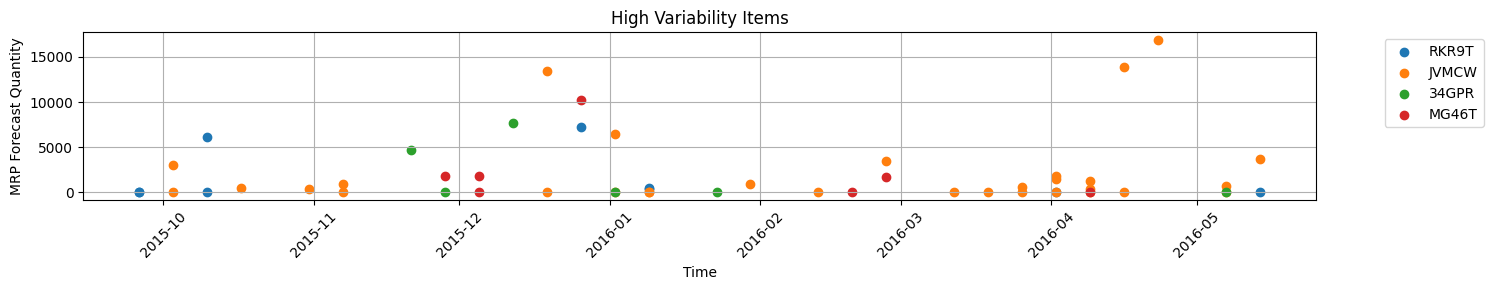

In [35]:
df_variability_ts = con.execute("""
SELECT
    COMP_ITEM_ID,
    VRSN_WEEK_STRT_DATE AS period,
    MRP_FCST_QTY AS qty
FROM inventory_processed
WHERE COMP_ITEM_ID IN (
    SELECT COMP_ITEM_ID
    FROM freq_outliers
    ORDER BY (p90 - p25) DESC
    LIMIT 4
)
ORDER BY period
""").df()

plt.figure(figsize=(15,3))

for item in df_variability_ts['COMP_ITEM_ID'].unique():
    subset = df_variability_ts[df_variability_ts['COMP_ITEM_ID'] == item]
    plt.scatter(subset['period'], subset['qty'], label=item)

plt.title("High Variability Items")
plt.xlabel("Time")
plt.ylabel("MRP Forecast Quantity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

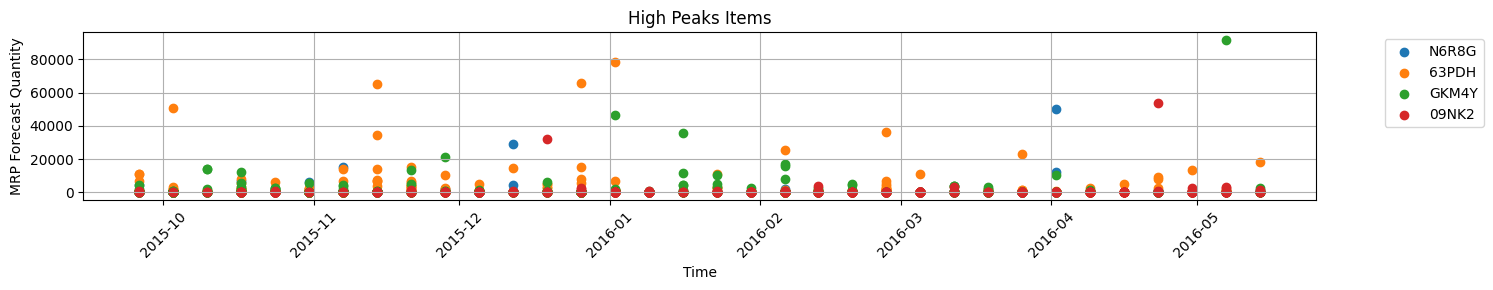

In [36]:
df_peak_ts = con.execute("""
SELECT
    COMP_ITEM_ID,
    VRSN_WEEK_STRT_DATE AS period,
    MRP_FCST_QTY AS qty
FROM inventory_processed
WHERE COMP_ITEM_ID IN (
    SELECT COMP_ITEM_ID
    FROM freq_outliers
    ORDER BY max_freq DESC
    LIMIT 4
)
ORDER BY period
""").df()

plt.figure(figsize=(15,3))

for item in df_peak_ts['COMP_ITEM_ID'].unique():
    subset = df_peak_ts[df_peak_ts['COMP_ITEM_ID'] == item]
    plt.scatter(subset['period'], subset['qty'], label=item)

plt.title("High Peaks Items")
plt.xlabel("Time")
plt.ylabel("MRP Forecast Quantity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

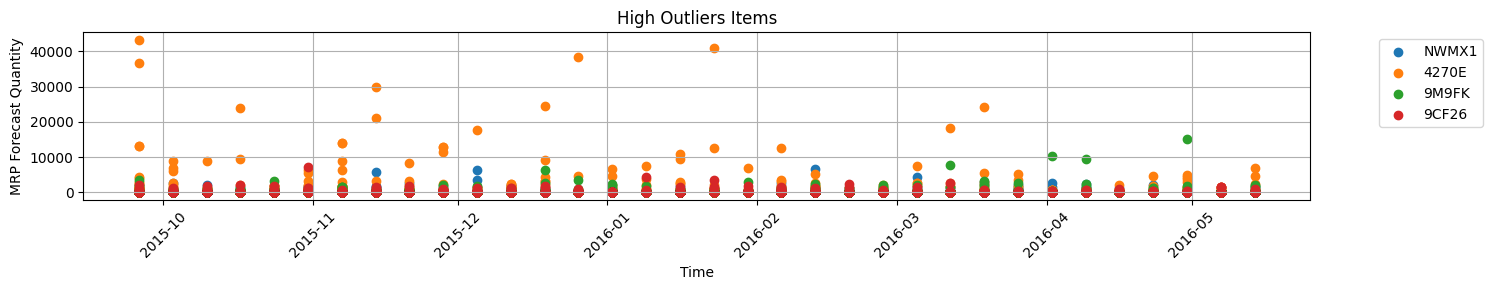

In [37]:
df_outliers_ts = con.execute("""
SELECT
    COMP_ITEM_ID,
    VRSN_WEEK_STRT_DATE AS period,
    MRP_FCST_QTY AS qty
FROM inventory_processed
WHERE COMP_ITEM_ID IN (
    SELECT COMP_ITEM_ID
    FROM freq_outliers
    ORDER BY count_outliers_above DESC
    LIMIT 4
)
ORDER BY period
""").df()

plt.figure(figsize=(15,3))

for item in df_outliers_ts['COMP_ITEM_ID'].unique():
    subset = df_outliers_ts[df_outliers_ts['COMP_ITEM_ID'] == item]
    plt.scatter(subset['period'], subset['qty'], label=item)

plt.title("High Outliers Items")
plt.xlabel("Time")
plt.ylabel("MRP Forecast Quantity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()

plt.show()

* Observa-se concentração de ocorrências em datas específicas (pontos alinhados verticalmente), indicando que o processo de planejamento é executado em momentos definidos (semanal, aparentemente).
* Diferentes componentes apresentam registros nas mesmas datas, sugerindo que o sistema realiza verificações em lote (batch).
* Os picos de demanda são irregulares e não seguem padrão temporal claro. Não há sazonalidade ou repetição consistente dos eventos de alta demanda, indicando ocorrência associada a eventos específicos.
* Nem todas as execuções do processo resultam em demanda efetiva. Há diversos registros com quantidade zero (vários pontos alinhados com a linha 0 do eixo vertical), reforçando que o sistema também atua como rotina de verificação, e não apenas de reposição.
* O processo de planejamento é seletivo. Nem todos os componentes aparecem em todas as datas de execução, indicando que apenas um subconjunto atende aos critérios para geração de registros.


## D) Carregamento dos dados (LOAD)

In [38]:
# Exportar a tabela inventory_processed para Excel
df_export = con.execute("""
SELECT * 
FROM inventory_processed
""").df()

df_export.to_excel("C:/Users/littl/OneDrive/Área de Trabalho/Dados/Portfolio/Supply chain/inventory_processed.xlsx", index=False)


## E) Diagnósticos/ insights
* A maioria dos processos (ON SCHEDULE, 94,4%) ocorre dentro do prazo, indicando bom alinhamento com o lead time.    

* Cerca de 50% das ocorrências não resultam em necessidade de reposição, sugerindo que o sistema atua também como mecanismo de verificação contínua. Isso pode refletir um monitoramento adequado ou um possível excesso de acionamentos no planejamento.    

* De forma geral, o planejamento da operação se mostra consistente, com a grande maioria das demandas sendo atendidas dentro do lead time esperado. Isso indica que, no nível macro, o sistema funciona de forma adequada.    

* No entanto, ao aprofundar a análise, observa-se que uma parcela significativa dos registros não corresponde a demandas reais. Esse comportamento sugere que o sistema não é utilizado apenas para reposição, mas também como ferramenta de monitoramento ou verificação operacional.    

* Esse padrão não está restrito a um tipo específico de estratégia de produção, aparecendo de forma distribuída, o que reforça que se trata de uma característica do processo.    

* Quando analisamos o volume das demandas, surge um segundo comportamento relevante: existem vários eventos com volumes muito acima do padrão, indicando possíveis situações excepcionais.    

* Ao observar os componentes individualmente, fica claro que alguns itens concentram:
    * maiores oscilações;
    * maior frequência de picos;
    * maior imprevisibilidade.
* Esses componentes se destacam como pontos de atenção dentro do sistema, pois podem gerar impacto no planejamento e no custo operacional.    

* Por fim, a análise ao longo do tempo sugere que a operação segue um ritmo recorrente, com padrões bem definidos de abertura de demandas, possivelmente associados a ciclos operacionais (como planejamento semanal ou reposição em lotes).

## F) Ações sugeridas
* A análise realizada não identificou falhas relevantes no processo de planejamento. Os indicadores apontam boa aderência ao lead time e um comportamento operacional consistente, o que sugere um sistema estável dentro do período analisado.    

* No entanto, algumas limitações do conjunto de dados indicam oportunidades claras de aprofundamento antes de qualquer tomada de decisão estratégica.    

* O principal ponto é o aspecto temporal. Um ano de dados não é suficiente para identificar sazonalidade ou padrões estruturais de demanda. A ampliação da base histórica permitiria avaliar tendências, ciclos e possíveis períodos críticos com maior confiabilidade.    

* Outro direcionamento importante é a análise em nível mais granular. Avaliações por componente, produto ou categoria podem revelar itens críticos ou comportamentos específicos que não aparecem na visão agregada.    

* A presença significativa de registros com quantidade nula, embora aparentemente faça parte da rotina operacional, merece uma análise direcionada para avaliar possíveis impactos em eficiência e custo operacional.    

* Também há oportunidade de aprofundar a análise da capacidade de resposta do sistema. Para isso, é importante compreender melhor o contexto operacional dos dados, especialmente os motivos associados às demandas nulas e às ocorrências de picos de demanda.    

* A integração com outras bases, como dados de estoque, pode contribuir para entender se essas variações estão relacionadas a disponibilidade de materiais, ajustes operacionais ou rotinas internas. Da mesma forma, a incorporação de informações de outros setores pode ajudar a contextualizar melhor o comportamento observado e permitir uma análise mais completa do processo.    

* Em resumo, o cenário atual não aponta problemas imediatos, mas há espaço para análises mais aprofundadas que podem gerar ganhos incrementais de eficiência e maior previsibilidade operacional.